# CelFDrive max-projection and SAHI example

This notebook treats the supplied 12-plane stack as four microscope positions with three Z planes each. It validates and max-projects each position **before** running CelFDrive. The stage coordinates are reproducible illustrative values, not calibrated coordinates for a real microscope.

In [1]:
from pathlib import Path
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import tifffile

def find_repository_root(start):
    for candidate in (start, *start.parents):
        if (candidate / "predict.py").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the CelFDrive repository root")

REPOSITORY_ROOT = find_repository_root(Path.cwd().resolve())
EXAMPLE_DIRECTORY = REPOSITORY_ROOT / "examples" / "max_projection_sahi"
SLICES_DIRECTORY = EXAMPLE_DIRECTORY / "z_slices"
PROJECTIONS_DIRECTORY = EXAMPLE_DIRECTORY / "max_projections"
OUTPUT_DIRECTORY = EXAMPLE_DIRECTORY / "outputs"
if str(REPOSITORY_ROOT) not in sys.path:
    sys.path.insert(0, str(REPOSITORY_ROOT))

import predict
print(f"Repository: {REPOSITORY_ROOT}")
print(f"Example: {EXAMPLE_DIRECTORY}")

Repository: C:\Users\Brook\Documents\Work\CelFDrive
Example: C:\Users\Brook\Documents\Work\CelFDrive\examples\max_projection_sahi


## Validate the position/Z grid

The expected ordering is `p1z1`, `p1z2`, `p1z3`, `p2z1`, …, `p4z3`. Every plane must be a 2304×2304 16-bit grayscale image.

In [2]:
filename_pattern = re.compile(r"p(?P<position>[1-4])z(?P<z>[1-3])\.tif$")
slice_paths = {}
for path in SLICES_DIRECTORY.glob("*.tif"):
    match = filename_pattern.fullmatch(path.name)
    if match:
        slice_paths[(int(match["position"]), int(match["z"]))] = path

expected_keys = {(position, z_index) for position in range(1, 5) for z_index in range(1, 4)}
if set(slice_paths) != expected_keys:
    missing = sorted(expected_keys - set(slice_paths))
    unexpected = sorted(set(slice_paths) - expected_keys)
    raise ValueError(f"Incomplete position/Z grid; missing={missing}, unexpected={unexpected}")

planes = {}
for key, path in sorted(slice_paths.items()):
    plane = tifffile.imread(path)
    if plane.shape != (2304, 2304) or plane.dtype != np.uint16:
        raise ValueError(f"{path.name} has unexpected shape/dtype: {plane.shape}, {plane.dtype}")
    planes[key] = plane

pd.DataFrame([
    {"position": position, "z_plane": z_index, "file": slice_paths[(position, z_index)].name,
     "shape": str(planes[(position, z_index)].shape), "dtype": str(planes[(position, z_index)].dtype)}
    for position, z_index in sorted(expected_keys)
])

,position,z_plane,file,shape,dtype
0,1,1,p1z1.tif,"(2304, 2304)",uint16
1,1,2,p1z2.tif,"(2304, 2304)",uint16
2,1,3,p1z3.tif,"(2304, 2304)",uint16
3,2,1,p2z1.tif,"(2304, 2304)",uint16
4,2,2,p2z2.tif,"(2304, 2304)",uint16
5,2,3,p2z3.tif,"(2304, 2304)",uint16
6,3,1,p3z1.tif,"(2304, 2304)",uint16
7,3,2,p3z2.tif,"(2304, 2304)",uint16
8,3,3,p3z3.tif,"(2304, 2304)",uint16
9,4,1,p4z1.tif,"(2304, 2304)",uint16


## Maximum-project each position

Projection is a pixel-wise maximum over the three Z planes belonging to one position. The four projections are written as lossless 16-bit TIFFs and stacked on the final axis for CelFDrive.

In [3]:
PROJECTIONS_DIRECTORY.mkdir(parents=True, exist_ok=True)
max_projections = []
for position in range(1, 5):
    z_stack = np.stack([planes[(position, z_index)] for z_index in range(1, 4)], axis=0)
    projection = np.max(z_stack, axis=0)
    projection_path = PROJECTIONS_DIRECTORY / f"p{position}_max.tif"
    tifffile.imwrite(projection_path, projection, photometric="minisblack", compression="zlib", metadata={"axes": "YX"})
    persisted = tifffile.imread(projection_path)
    if not np.array_equal(persisted, projection):
        raise RuntimeError(f"Persisted projection differs from computed projection: {projection_path}")
    max_projections.append(projection)

montage_stack = np.stack(max_projections, axis=-1)
assert montage_stack.shape == (2304, 2304, 4)
print(f"CelFDrive montage shape: {montage_stack.shape}; dtype: {montage_stack.dtype}")

CelFDrive montage shape: (2304, 2304, 4); dtype: uint16


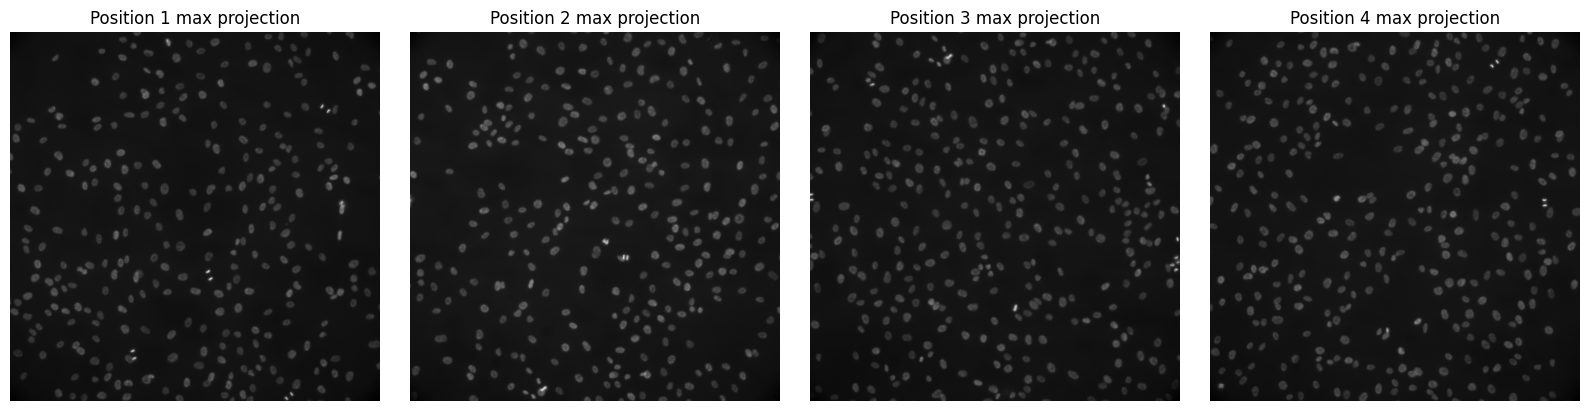

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)
for position, (axis, projection) in enumerate(zip(axes, max_projections), start=1):
    axis.imshow(projection, cmap="gray")
    axis.set_title(f"Position {position} max projection")
    axis.axis("off")
plt.show()

## Configure the 99.99 model and example-only SAHI mode

The repository default remains standard tiling. This notebook changes the in-memory configuration only: confidence 0.5, 640 px slices, 25% overlap, batches of six, and class-aware greedy NMM with IOU threshold 0.1.

In [5]:
config = predict.load_predict_config(REPOSITORY_ROOT / "celfdrive_predict.yaml")
config["project"]["repo_path"] = str(REPOSITORY_ROOT)
config["model"]["weights_path"] = str(REPOSITORY_ROOT / "Models" / "yolo11x_p99p99_bg05" / "weights" / "best.pt")
config["inference"]["mode"] = "sahi"
config["inference"]["sahi"].update({
    "confidence_threshold": 0.5,
    "slice_size_px": 640,
    "overlap_ratio": 0.25,
    "tile_batch_size": 6,
    "merge_iou_threshold": 0.1,
})
config["logging"]["root_dir"] = str(OUTPUT_DIRECTORY)
config["logging"]["use_date_subfolder"] = False
config["plotting"]["enabled"] = True
predict.config = config
predict.model = None
predict.experiment_path = None
assert Path(config["model"]["weights_path"]).is_file()
pd.Series({"model": config["model"]["weights_path"], "mode": config["inference"]["mode"], **config["inference"]["sahi"]})

model                   C:\Users\Brook\Documents\Work\CelFDrive\Models...
mode                                                                 sahi
confidence_threshold                                                  0.5
slice_size_px                                                         640
overlap_ratio                                                        0.25
tile_batch_size                                                         6
merge_iou_threshold                                                   0.1
dtype: object

## Create reproducible illustrative stage coordinates

The positions form a widely spaced 2×2 grid with seeded random jitter. The representative stage Z is retained after max projection; the projection does not estimate which source Z plane contained a detection.

In [6]:
rng = np.random.default_rng(42)
base_x = np.array([10_000.0, 12_000.0, 10_000.0, 12_000.0])
base_y = np.array([5_000.0, 5_000.0, 7_000.0, 7_000.0])
stage_x = base_x + rng.uniform(-100, 100, size=4)
stage_y = base_y + rng.uniform(-100, 100, size=4)
stage_z = rng.uniform(40, 60, size=4)
position_table = pd.DataFrame({
    "position": np.arange(1, 5), "stage_x_um": stage_x, "stage_y_um": stage_y, "stage_z_um": stage_z
})
position_table

,position,stage_x_um,stage_y_um,stage_z_um
0,1,10054.791210,4918.835470,42.562273
1,2,11987.775688,5095.124470,49.007719
2,3,10071.719584,7052.227940,47.415960
3,4,12039.473606,7057.212861,58.535300


## Run CelFDrive

In [7]:
targets = predict.get_target_locations(
    stage_x=stage_x,
    stage_y=stage_y,
    stage_z=stage_z,
    image=montage_stack,
    xy_pixel_spacing_um=0.315,
    x_stage_direction=1,
    y_stage_direction=1,
    coordinate_mode="stage",
)
count, target_x, target_y, target_z, scripts, names, comments = targets
target_table = pd.DataFrame({
    "target_x_um": target_x, "target_y_um": target_y, "target_z_um": target_z,
    "capture_script": scripts, "name": names, "comment": comments,
})
if count != len(target_table) or not np.isfinite(target_table[["target_x_um", "target_y_um", "target_z_um"]].to_numpy(dtype=float)).all():
    raise RuntimeError("CelFDrive returned an invalid target table")
print(f"CelFDrive returned {count} capture targets")
target_table

CelFDrive returned 32 capture targets


,target_x_um,target_y_um,target_z_um,capture_script,name,comment
0,10038.848188,6919.604135,47.41596,floifmHighres,earlyprometaphase Highres x 10038.848188108253...,Highres
1,11772.079173,7155.107071,58.5353,floifmHighres,earlyprometaphase Highres x 11772.079172828475...,Highres
2,12146.677696,7046.830589,58.5353,floifmHighres,earlyprometaphase Highres x 12146.677695777693...,Highres
3,11918.627251,7016.971765,58.5353,floifmHighres,earlyprometaphase Highres x 11918.627251136579...,Highres
4,9780.795927,4716.133873,42.562273,floifmHighres,"prophase Highres x 9780.795927118419, Y 4716.1...",Highres
5,11650.294546,4834.375222,49.007719,floifmHighres,"prophase Highres x 11650.294545639314, Y 4834....",Highres
6,9830.446272,7309.761051,47.41596,floifmHighres,"prophase Highres x 9830.446272214698, Y 7309.7...",Highres
7,12005.359317,4839.373367,49.007719,floifmHighres,"prophase Highres x 12005.359317100801, Y 4839....",Highres
8,12001.762349,5139.782988,49.007719,floifmHighres,"prometaphase Highres x 12001.762349327364, Y 5...",Highres
9,9997.109949,4570.969989,42.562273,floifmHighres,"prometaphase Highres x 9997.109949335216, Y 45...",Highres


## Inspect CelFDrive overlays

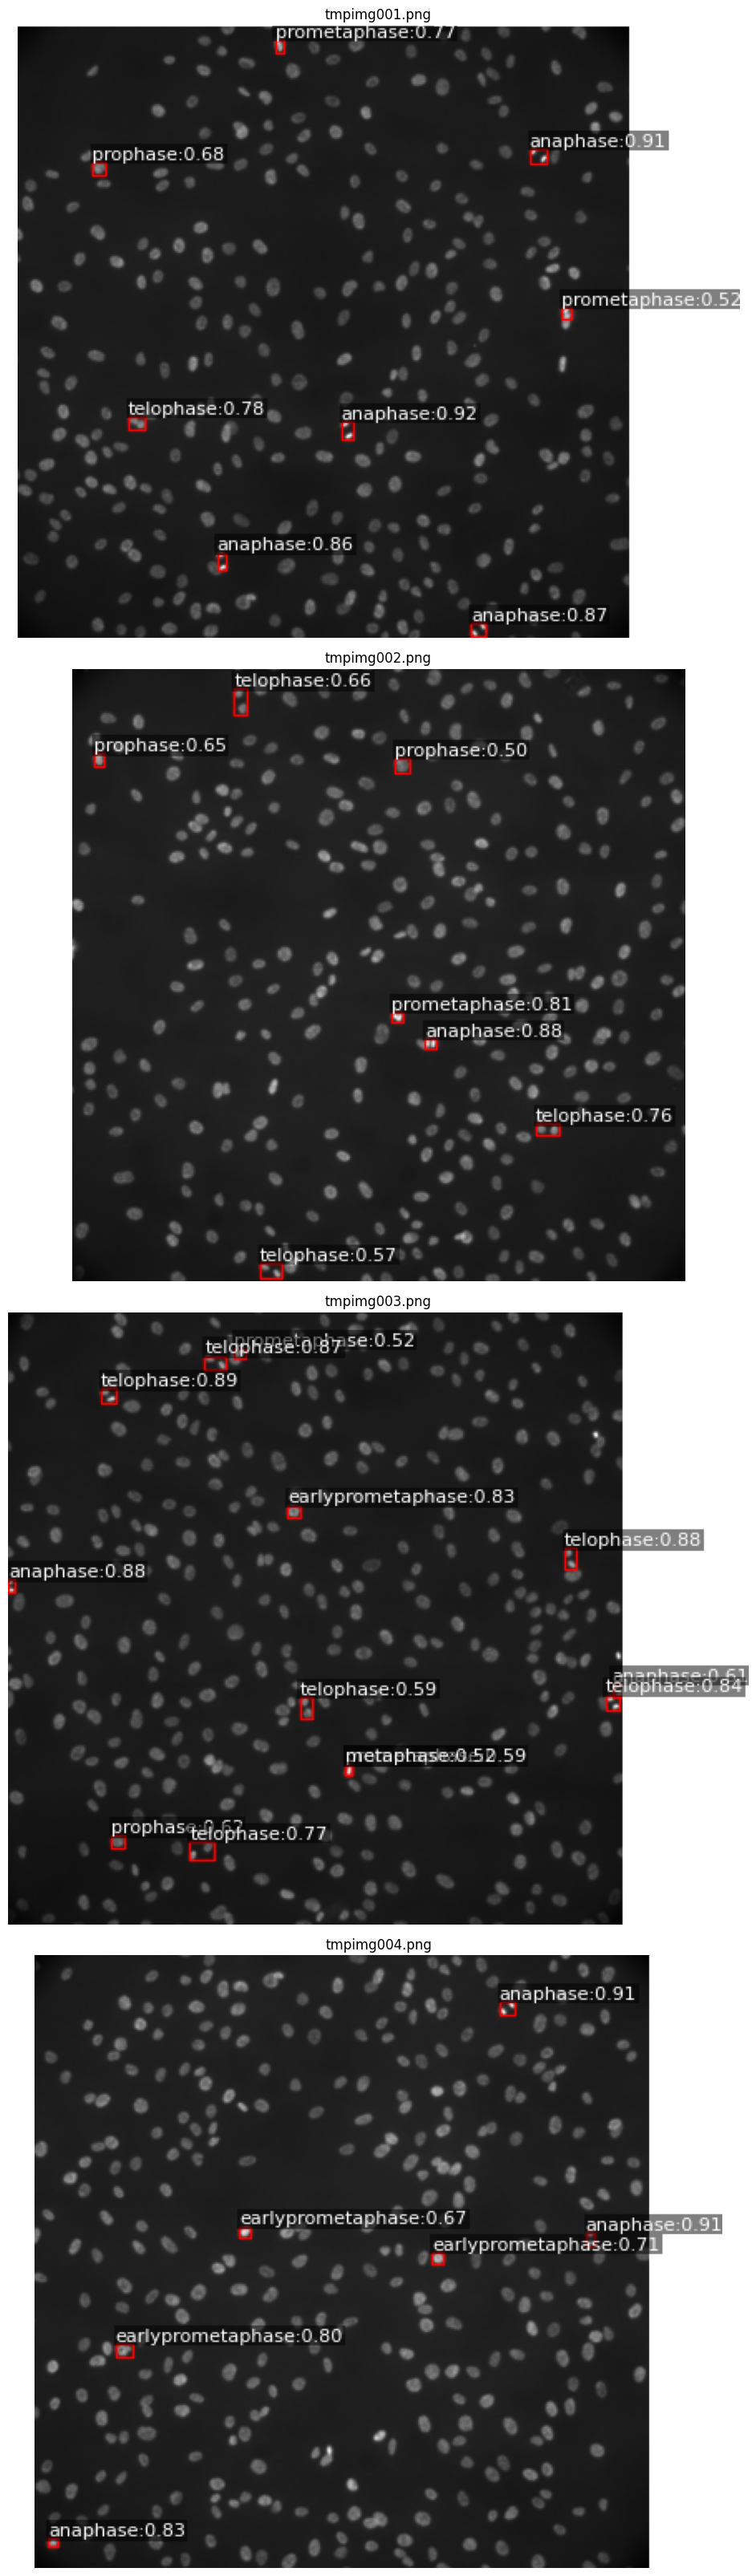

Annotated outputs: C:\Users\Brook\Documents\Work\CelFDrive\examples\max_projection_sahi\outputs\exp004


In [8]:
from IPython.display import display

overlay_paths = sorted(predict.experiment_path.glob("*.png"))
if len(overlay_paths) != 4:
    raise RuntimeError(f"Expected four annotated projections, found {len(overlay_paths)}")
fig, axes = plt.subplots(4, 1, figsize=(14, 32), constrained_layout=True)
for axis, overlay_path in zip(axes, overlay_paths):
    with Image.open(overlay_path) as overlay:
        overlay.verify()
    axis.imshow(Image.open(overlay_path))
    axis.set_title(overlay_path.name)
    axis.axis("off")
display(fig)
plt.close(fig)
print(f"Annotated outputs: {predict.experiment_path}")